In [ ]:
import requests
import pandas as pd
import re
import html
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as plotly_go
import os
from bs4 import BeautifulSoup
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google import genai
from dotenv import load_dotenv

In [9]:
load_dotenv()

API_KEY = os.getenv("API_KEY_GEMINI")
URL = "https://graphql.anilist.co"
PER_PAGE = 50
PAGES = (1, 2)  # 2 páginas x 50 itens = top 100
REVIEWS_PER_ANIME = 3

def clean_description(text):
    """Remove tags HTML da coluna description."""
    if not isinstance(text, str):
        return text
    
    # O BeautifulSoup para remover tags html.
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

def clean_body(text):
    """Trata a mistura de HTML, Markdown e tags customizadas da coluna body."""
    if not isinstance(text, str):
        return text
    
    # 1. Decodificar entidades HTML (ex: &#120328; vira o caractere real)
    text = html.unescape(text)
    
    # 2. Remover tags de imagem customizadas (ex: ~~~img700(link)~~~)
    text = re.sub(r'~~~img\d*\([^)]*\)~~~', '', text)
    
    # 3. Remover os delimitadores customizados ~~~ mantendo o texto de dentro (se houver)
    text = re.sub(r'~~~(.*?)~~~', r'\1', text, flags=re.DOTALL)
    
    # 4. Remover tags HTML (ex: <p align="justify">, <h1>, <hr>)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)
    
    # 5. Converter links em Markdown [texto](url) para apenas 'texto'
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    
    # 6. Remover formatação Markdown de ênfase (*, **, ***, _, __, ___)
    # Captura o texto que está entre esses símbolos e descarta os símbolos
    text = re.sub(r'[*_]{1,3}([^*_]+)[*_]{1,3}', r'\1', text)
    
    # 7. Remover marcadores de cabeçalho (#) e blockquotes (>) do início das linhas
    text = re.sub(r'^[>#]+\s*', '', text, flags=re.MULTILINE)
    
    # 8. Normalizar os espaços e quebras de linha (evita múltiplos espaços seguidos)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

QUERY = """
query($page: Int!, $perPage: Int!, $sort: [MediaSort], $reviewSort: [ReviewSort], $reviewPerPage: Int, $isMain: Boolean) {
  Page(page: $page, perPage: $perPage) {
    pageInfo {
      currentPage
      hasNextPage
    }
    media(type: ANIME, sort: $sort) {
      id
      title {
        romaji
        english
      }
      averageScore
      popularity
      description
      duration
      episodes
      format
      genres
      reviews(sort: $reviewSort, perPage: $reviewPerPage) {
        edges {
          node {
            rating
            ratingAmount
            body
          }
        }
      }
      startDate {
        month
        year
      }
      studios(isMain: $isMain) {
        edges {
          node {
            name
          }
        }
      }
    }
  }
}
"""

def fetch_anilist_anime(sort_key, pages=PAGES, per_page=PER_PAGE, review_sort="RATING_DESC", review_per_page=REVIEWS_PER_ANIME, is_main=True):
    """
    Baixa múltiplas páginas da AniList e devolve três DataFrames:
    - df_media
    - df_reviews
    - df_studios
    """
    rows_main = []
    rows_reviews = []
    rows_studios = []

    session = requests.Session()
    session.headers.update({"Content-Type": "application/json"})

    for page in pages:
        variables = {
            "page": page,
            "perPage": per_page,
            "sort": [sort_key],
            "reviewSort": [review_sort],
            "reviewPerPage": review_per_page,
            "isMain": is_main,
        }

        response = session.post(
            URL,
            json={"query": QUERY, "variables": variables},
            timeout=30,
        )
        response.raise_for_status()
        data = response.json()

        if "errors" in data:
            raise Exception(data["errors"])

        media_list = data["data"]["Page"]["media"]

        for media in media_list:
            media_id = media["id"]
            title = media.get("title") or {}
            title_romaji = title.get("romaji")
            title_english = title.get("english")

            studios = []
            if media.get("studios") and media["studios"].get("edges"):
                studios = [
                    edge["node"]["name"]
                    for edge in media["studios"]["edges"]
                    if edge.get("node")
                ]

            rows_main.append({
                "page": page,
                "id": media_id,
                "title_romaji": title_romaji,
                "title_english": title_english,
                "averageScore": media.get("averageScore"),
                "popularity": media.get("popularity"),
                "description": media.get("description"),
                "duration": media.get("duration"),
                "episodes": media.get("episodes"),
                "format": media.get("format"),
                "genres": ", ".join(media["genres"]) if media.get("genres") else None,
                "start_month": media["startDate"].get("month") if media.get("startDate") else None,
                "start_year": media["startDate"].get("year") if media.get("startDate") else None,
                "studios_main": ", ".join(studios) if studios else None,
            })

            if media.get("reviews") and media["reviews"].get("edges"):
                for review_edge in media["reviews"]["edges"]:
                    node = review_edge.get("node", {})
                    rows_reviews.append({
                        "page": page,
                        "media_id": media_id,
                        "title_romaji": title_romaji,
                        "rating": node.get("rating"),
                        "ratingAmount": node.get("ratingAmount"),
                        "body": node.get("body"),
                    })

            if media.get("studios") and media["studios"].get("edges"):
                for studio_edge in media["studios"]["edges"]:
                    node = studio_edge.get("node", {})
                    rows_studios.append({
                        "page": page,
                        "media_id": media_id,
                        "title_romaji": title_romaji,
                        "studio_name": node.get("name"),
                    })

    df_media = pd.DataFrame(rows_main)
    df_reviews = pd.DataFrame(rows_reviews)
    df_studios = pd.DataFrame(rows_studios)

    df_media["description"] = df_media["description"].apply(clean_description)
    df_reviews["body"] = df_reviews["body"].apply(clean_body)

    return df_media, df_reviews, df_studios

# Top 100 por avaliação
df_media_score, df_reviews_score, df_studios_score = fetch_anilist_anime("SCORE_DESC")

# Top 100 por popularidade
df_media_popularity, df_reviews_popularity, df_studios_popularity = fetch_anilist_anime("POPULARITY_DESC")

display("df_media_score:")
display(df_media_score.head())

display("df_reviews_score:")
display(df_reviews_score.head())

display("df_studios_score:")
display(df_studios_score.head())

display("df_media_popularity:")
display(df_media_popularity.head())

display("df_reviews_popularity:")
display(df_reviews_popularity.head())

display("df_studios_popularity:")
display(df_studios_popularity.head())

'df_media_score:'

,page,id,title_romaji,title_english,averageScore,popularity,description,duration,episodes,format,genres,start_month,start_year,studios_main
0,1,154587,Sousou no Frieren,Frieren: Beyond Journey’s End,91,428587,The adventure is over but life goes on for an ...,24,28.0,TV,"Adventure, Drama, Fantasy",9,2023,MADHOUSE
1,1,114129,Gintama: THE FINAL,Gintama: THE VERY FINAL,91,52388,Gintama: THE FINAL is the 3rd and final film a...,104,1.0,MOVIE,"Action, Comedy, Drama, Sci-Fi",1,2021,Bandai Namco Pictures
2,1,20996,Gintama°,Gintama Season 3,90,115323,"Gintoki, Shinpachi, and Kagura return as the f...",24,51.0,TV,"Action, Comedy, Drama, Sci-Fi",4,2015,Bandai Namco Pictures
3,1,171627,Chainsaw Man: Reze-hen,Chainsaw Man – The Movie: Reze Arc,90,195141,Theatrical follow-up to Chainsaw Man . Denji b...,100,1.0,MOVIE,"Action, Drama, Horror, Romance, Supernatural",9,2025,MAPPA
4,1,182469,ONE PIECE FAN LETTER,ONE PIECE FAN LETTER,90,51978,To commemorate the 25th anniversary of the ONE...,25,1.0,SPECIAL,"Action, Adventure, Fantasy",10,2024,Toei Animation


'df_reviews_score:'

,page,media_id,title_romaji,rating,ratingAmount,body
0,1,154587,Sousou no Frieren,316,358,"This review is spoiler-free. (Note: If ""Friere..."
1,1,154587,Sousou no Frieren,225,256,Contains spoilers ********* Time is inevitable...
2,1,154587,Sousou no Frieren,135,337,"""It would be embarrassing when we met again."" ..."
3,1,114129,Gintama: THE FINAL,275,296,img1000(https://cdn.discordapp.com/attachments...
4,1,114129,Gintama: THE FINAL,191,206,A spoiler-free review on ALL the seasons of th...


'df_studios_score:'

...

,page,id,title_romaji,title_english,averageScore,popularity,description,duration,episodes,format,genres,start_month,start_year,studios_main
0,1,16498,Shingeki no Kyojin,Attack on Titan,85,994488,"Several hundred years ago, humans were nearly ...",24,25.0,TV,"Action, Drama, Fantasy, Mystery",4,2013,WIT STUDIO
1,1,101922,Kimetsu no Yaiba,Demon Slayer: Kimetsu no Yaiba,83,941936,"It is the Taisho Period in Japan. Tanjiro, a k...",24,26.0,TV,"Action, Adventure, Drama, Fantasy, Supernatural",4,2019,ufotable
2,1,113415,Jujutsu Kaisen,JUJUTSU KAISEN,84,910017,"A boy fights... for ""the right death."" Hardshi...",24,24.0,TV,"Action, Drama, Supernatural",10,2020,MAPPA
3,1,1535,DEATH NOTE,Death Note,84,906291,Light Yagami is a genius high school student w...,23,37.0,TV,"Mystery, Psychological, Supernatural, Thriller",10,2006,MADHOUSE
4,1,21459,Boku no Hero Academia,My Hero Academia,77,831233,What would the world be like if 80 percent of ...,24,13.0,TV,"Action, Adventure, Comedy",4,2016,bones


'df_reviews_popularity:'

,page,media_id,title_romaji,rating,ratingAmount,body
0,1,16498,Shingeki no Kyojin,214,254,[This review will contain Spoilers for the sho...
1,1,16498,Shingeki no Kyojin,204,697,"Shingeki no Kyoujin, AKA Attack on Titan, is a..."
2,1,16498,Shingeki no Kyojin,109,124,"When I first watched Attack on Titan, I wasn’t..."
3,1,101922,Kimetsu no Yaiba,1211,1875,I am gonna be totally honest here. I never tho...
4,1,101922,Kimetsu no Yaiba,282,519,"Demon Slayer is a Japanese manga series, which..."


'df_studios_popularity:'

,page,media_id,title_romaji,studio_name
0,1,16498,Shingeki no Kyojin,WIT STUDIO
1,1,101922,Kimetsu no Yaiba,ufotable
2,1,113415,Jujutsu Kaisen,MAPPA
3,1,1535,DEATH NOTE,MADHOUSE
4,1,21459,Boku no Hero Academia,bones


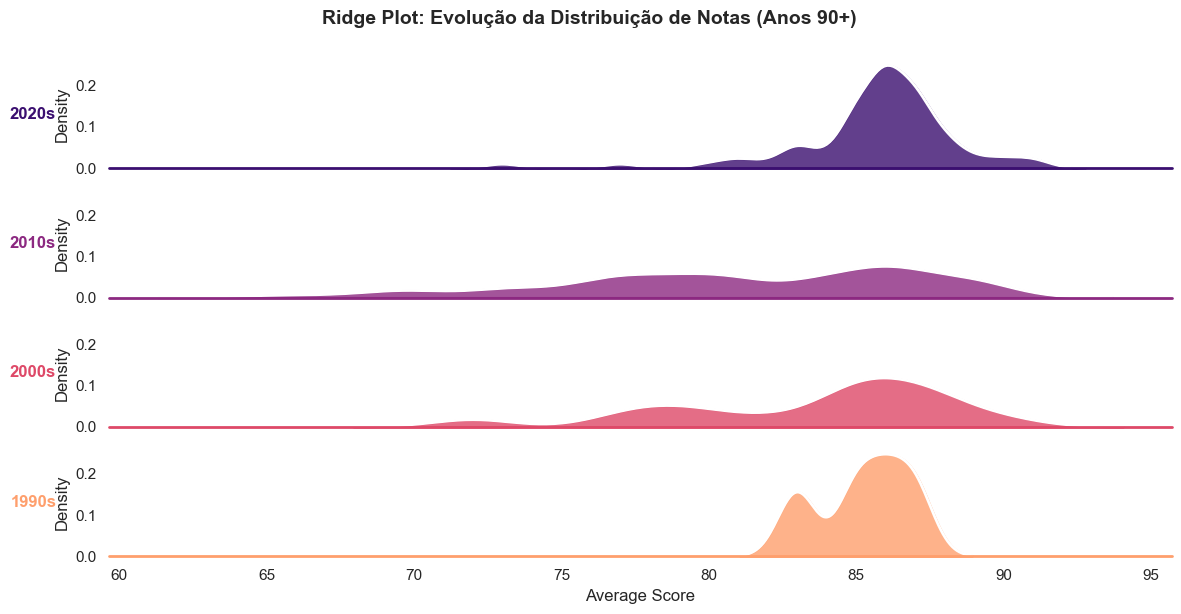

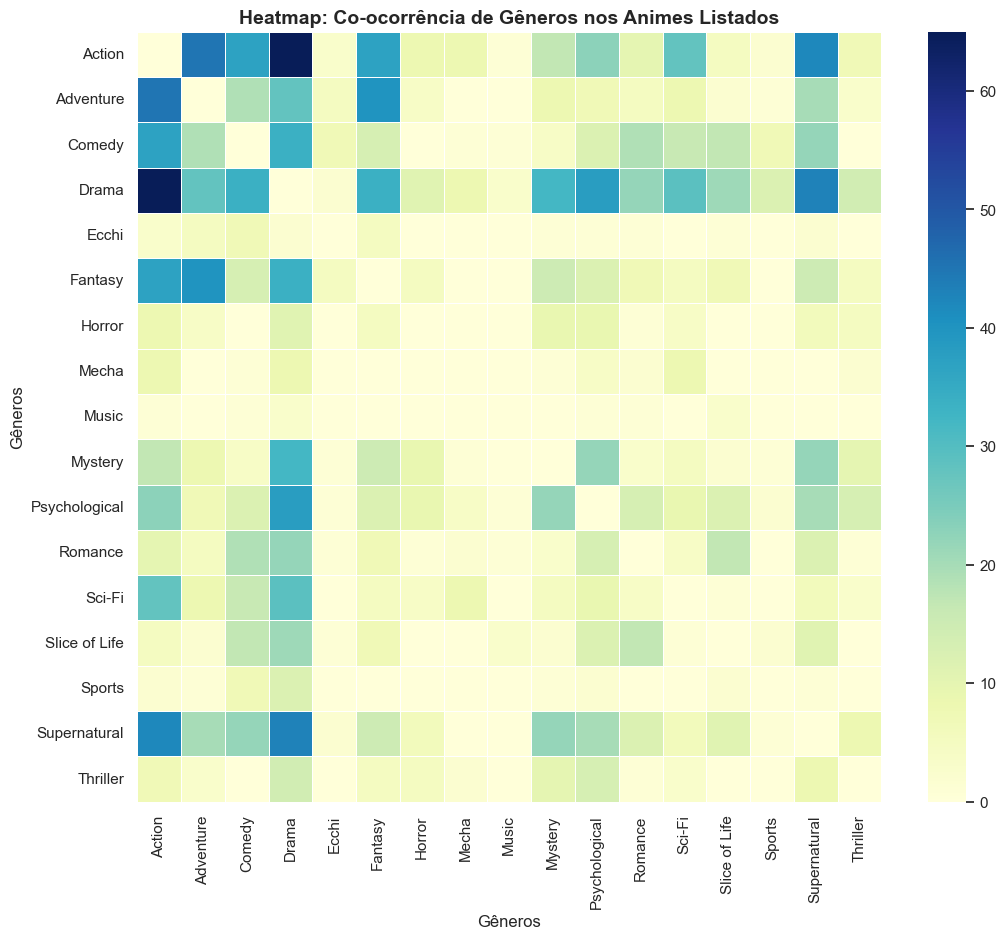


--- Analisando o K ideal (Elbow & Silhouette) ---


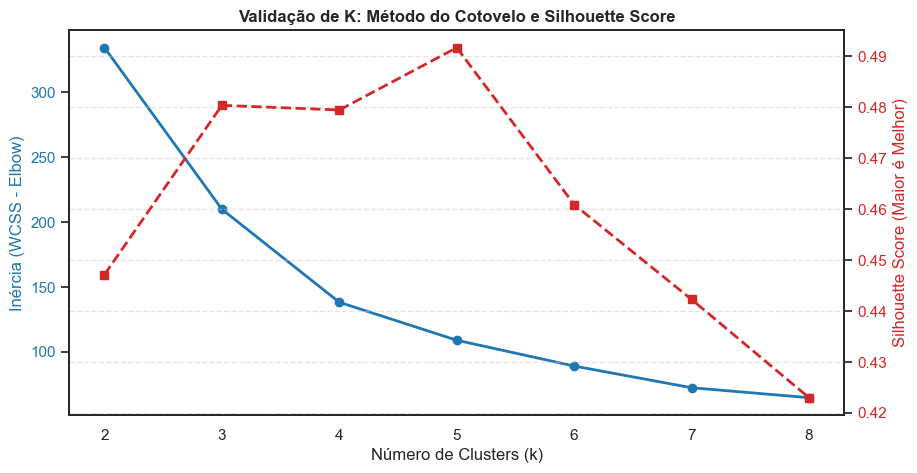

➜ Número ideal de clusters escolhido: 5


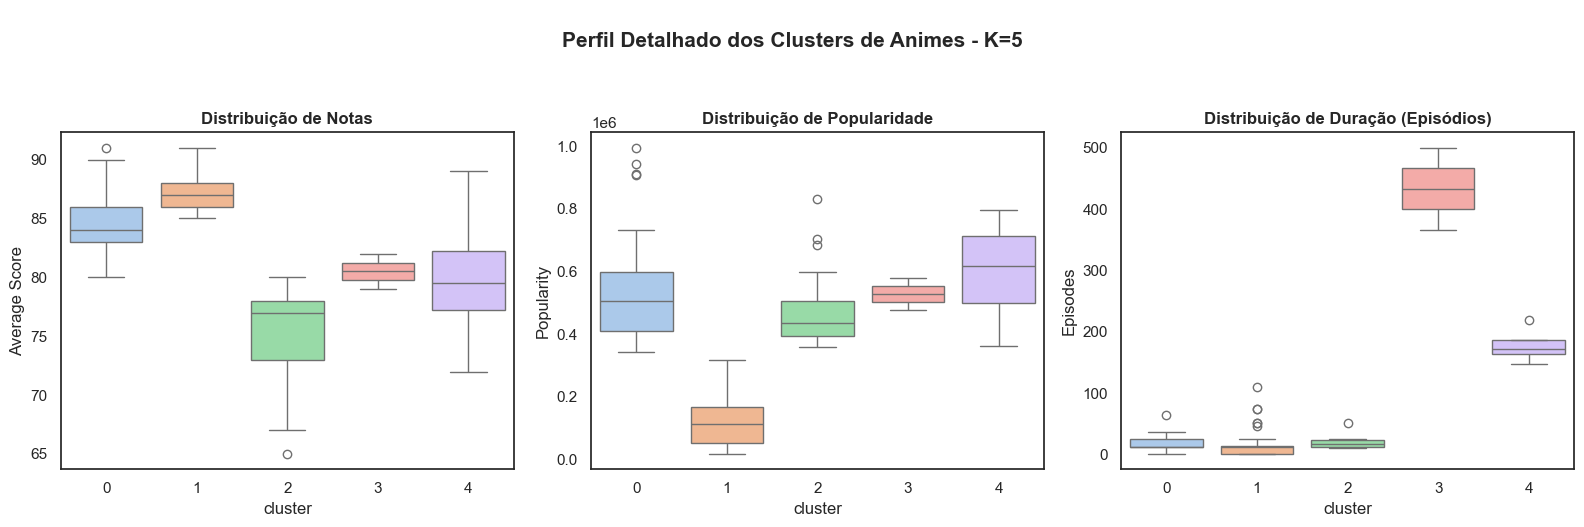


Perfis dos Clusters (Médias Reais):


,averageScore,popularity,episodes,qtd_animes
cluster,,,,
0,84.5,528542.9,17.0,56
1,86.8,119676.4,15.1,77
2,75.4,462430.6,19.0,40
3,80.5,527430.0,433.0,2
4,80.0,597365.0,178.2,4



--- Gerando Relatório de definições para 5 Grupos ---
🤖 Relatório do Gemini:

Aqui estão as definições para cada cluster:

---

### Cluster 0 ###
**Nome criativo do cluster**: Blockbusters de Adrenalina
**Público-alvo (Persona)**: Espectadores que buscam produções audiovisuais de ponta com animação deslumbrante e narrativas intensas. Fãs de ação visceral, mistério e temas sombrios, que valorizam alta qualidade de produção.
**Principal gatilho de engajamento**: Ação espetacular, reviravoltas chocantes e mistérios envolventes que geram discussões e teorias. A experiência cinematográfica e a intensidade dramática.

### Cluster 1 ###
**Nome criativo do cluster**: Enredos Brilhantes
**Público-alvo (Persona)**: Fãs de narrativas inteligentes e bem construídas, que apreciam tramas elaboradas e desenvolvimento profundo de personagens. Espectadores que valorizam a profundidade psicológica, o mistério e o humor astuto.
**Principal gatilho de engajamento**: A satisfação intelectual de desvendar 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as plotly_go
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google import genai

# ==========================================
# 0. Preparação dos Dados Consolidada
# ==========================================
df_media = pd.concat([df_media_score, df_media_popularity]).drop_duplicates(subset=['id']).reset_index(drop=True)
df_reviews = pd.concat([df_reviews_score, df_reviews_popularity]).drop_duplicates(subset=['media_id', 'body']).reset_index(drop=True)
df_studios = pd.concat([df_studios_score, df_studios_popularity]).drop_duplicates().reset_index(drop=True)

df_media['episodes'] = df_media['episodes'].fillna(df_media['episodes'].median())
df_media['averageScore'] = df_media['averageScore'].fillna(df_media['averageScore'].median())
df_media['start_year'] = pd.to_numeric(df_media['start_year'], errors='coerce')

# Extraindo apenas o primeiro gênero principal para simplificar a visão de nicho
df_media['main_genre'] = df_media['genres'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else 'Desconhecido')

# Calculando o tamanho das reviews
df_reviews['review_length'] = df_reviews['body'].astype(str).apply(len)

# ==========================================
# 1. Visualizações
# ==========================================

def plot_dumbbell_hidden_gems(df):
    """ 
    Gráfico 1: Dumbbell Plot 
    """
    df_plot = df.copy()
    df_plot['rank_score'] = df_plot['averageScore'].rank(ascending=False, method='min')
    df_plot['rank_pop'] = df_plot['popularity'].rank(ascending=False, method='min')
    df_plot['rank_diff'] = df_plot['rank_pop'] - df_plot['rank_score']
    
    top_diffs = df_plot.sort_values(by='rank_diff', ascending=False).head(15)
    
    fig = plotly_go.Figure()
    for i, row in top_diffs.iterrows():
        fig.add_trace(plotly_go.Scatter(x=[row['rank_score'], row['rank_pop']], y=[row['title_romaji'], row['title_romaji']],
                                        mode='lines', line=dict(color='gray', width=2), showlegend=False))
        fig.add_trace(plotly_go.Scatter(x=[row['rank_score']], y=[row['title_romaji']], mode='markers',
                                        marker=dict(color='gold', size=12, line=dict(color='black', width=1)),
                                        name='Rank de Nota' if i == top_diffs.index[0] else None,
                                        showlegend=True if i == top_diffs.index[0] else False))
        fig.add_trace(plotly_go.Scatter(x=[row['rank_pop']], y=[row['title_romaji']], mode='markers',
                                        marker=dict(color='purple', size=12, line=dict(color='black', width=1)),
                                        name='Rank de Popularidade' if i == top_diffs.index[0] else None,
                                        showlegend=True if i == top_diffs.index[0] else False))

    fig.update_layout(title="Dumbbell Plot: Hidden Gems (Rank Nota vs Rank Popularidade)",
                      yaxis_title="", height=600, xaxis=dict(autorange="reversed"))
    fig.show()

def plot_ridge_score_decades(df):
    """
    Gráfico 2: Ridge Plot
    """
    df_ridge = df.dropna(subset=['start_year', 'averageScore']).copy()
    df_ridge['Decade'] = (df_ridge['start_year'] // 10 * 10).astype(int).astype(str) + "s"
    df_ridge = df_ridge[df_ridge['start_year'] >= 1990]
    
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    g = sns.FacetGrid(df_ridge, row="Decade", hue="Decade", aspect=8, height=1.5, palette="magma")
    
    g.map(sns.kdeplot, "averageScore", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
    g.map(sns.kdeplot, "averageScore", clip_on=False, color="w", lw=2, bw_adjust=.5)
    g.map(plt.axhline, y=0, lw=2, clip_on=False)
    
    def label_decade(x, color, label):
        ax = plt.gca()
        ax.text(-0.05, 0.5, label, fontweight="bold", color=color, ha="right", va="center", transform=ax.transAxes)
                
    g.map(label_decade, "averageScore")
    
    # AJUSTE: hspace=0.2 garante que os eixos tenham espaço vertical, sem sobreposição
    g.figure.subplots_adjust(hspace=0.2)
    g.set_titles("")
    g.despine(bottom=True, left=True)
    plt.suptitle("Ridge Plot: Evolução da Distribuição de Notas (Anos 90+)", y=1.02, fontsize=14, fontweight="bold")
    plt.xlabel("Average Score")
    plt.show()

def plot_genre_cooccurrence(df):
    """
    Gráfico 3: Matriz de Correlação de Gêneros (Co-ocorrência)
    """
    df_genres = df[['id', 'genres']].dropna().copy()
    # Transformando a string de gêneros em lista
    df_genres['genres'] = df_genres['genres'].str.split(', ')
    # Explodindo para que cada gênero tenha sua linha
    df_exploded = df_genres.explode('genres')
    
    # Criando matriz de contingência/co-ocorrência
    crosstab = pd.crosstab(df_exploded['id'], df_exploded['genres'])
    co_occurrence = crosstab.T.dot(crosstab)
    
    # Zerando a diagonal principal (gênero com ele mesmo)
    np.fill_diagonal(co_occurrence.values, 0)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(co_occurrence, cmap="YlGnBu", annot=False, linewidths=.5)
    plt.title("Heatmap: Co-ocorrência de Gêneros nos Animes Listados", fontsize=14, fontweight="bold")
    plt.xlabel("Gêneros")
    plt.ylabel("Gêneros")
    plt.show()

def plot_studio_dominance_treemap(df_media, df_studios):
    """
    Gráfico 4 Treemap de Dominância de Estúdios e Gêneros.
    """
    # Mesclando dados de mídia com estúdios para ter 1 linha por estúdio x anime
    df_merged = df_media[['id', 'title_romaji', 'averageScore', 'main_genre']].merge(
        df_studios[['media_id', 'studio_name']], left_on='id', right_on='media_id'
    )
    
    # Agrupando para pegar a contagem de animes e a nota média por estúdio/gênero
    df_tree = df_merged.groupby(['studio_name', 'main_genre']).agg(
        anime_count=('id', 'count'),
        avg_score=('averageScore', 'mean')
    ).reset_index()
    
    # Filtrando apenas estúdios com mais de 1 produção no Top 100 para evitar excesso de bloquinhos
    df_tree = df_tree[df_tree.groupby('studio_name')['anime_count'].transform('sum') > 1]

    fig = px.treemap(
        df_tree, 
        path=[px.Constant("Top 100 Animes"), 'studio_name', 'main_genre'], 
        values='anime_count',
        color='avg_score', 
        hover_data=['anime_count'],
        color_continuous_scale='Viridis',
        title='Treemap: Monopólio de Nichos (Estúdios vs Gêneros Principais)'
    )
    fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
    fig.show()

def plot_season_performance(df):
    """
    Gráfico 5: BarPlot de Sazonalidade.
    """
    df_season = df.dropna(subset=['start_month']).copy()
    
    # Mapeando os meses nas temporadas japonesas
    conditions = [
        df_season['start_month'].isin([1, 2, 3]),
        df_season['start_month'].isin([4, 5, 6]),
        df_season['start_month'].isin([7, 8, 9]),
        df_season['start_month'].isin([10, 11, 12])
    ]
    choices = ['Inverno (Jan-Mar)', 'Primavera (Abr-Jun)', 'Verão (Jul-Set)', 'Outono (Out-Dez)']
    df_season['season'] = np.select(conditions, choices, default='Desconhecido')
    
    season_stats = df_season.groupby('season').agg(
        avg_popularity=('popularity', 'mean'),
        anime_count=('id', 'count')
    ).reset_index()
    
    # Ordenando pela popularidade
    season_stats = season_stats.sort_values(by='avg_popularity', ascending=False)
    
    fig = px.bar(
        season_stats, 
        x='season', 
        y='avg_popularity', 
        color='avg_popularity',
        text='anime_count',
        title='Média de Popularidade por Temporada (Japão) de Lançamento',
        labels={'season': 'Temporada de Lançamento', 'avg_popularity': 'Popularidade Média'},
        color_continuous_scale='Sunset'
    )
    fig.update_traces(texttemplate='Qtd: %{text}', textposition='outside')
    fig.update_layout(xaxis={'categoryorder':'total descending'}, yaxis_title="Popularidade Média")
    fig.show()

# ==========================================
# 2. Machine Learning: Otimização de Clusters
# ==========================================

def optimize_and_run_kmeans(df):
    """
    K-Means: Utiliza o Método do Cotovelo (Elbow) e o Silhouette Score
    para determinar o K ideal.
    """
    print("\n--- Analisando o K ideal (Elbow & Silhouette) ---")
    features = ['averageScore', 'popularity', 'episodes']
    X = df[features].copy()
    
    # Padronizando os dados para que as variáveis estejam na mesma escala
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    wcss = []
    silhouette_scores = []
    k_range = range(2, 9)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
    
    # Plotando Elbow e Silhouette lado a lado
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = 'tab:blue'
    ax1.set_xlabel('Número de Clusters (k)')
    ax1.set_ylabel('Inércia (WCSS - Elbow)', color=color)
    ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Silhouette Score (Maior é Melhor)', color=color)
    ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='dashed')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Validação de K: Método do Cotovelo e Silhouette Score', fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    # Selecionando o K ideal automaticamente com base no melhor Silhouette
    best_k = k_range[np.argmax(silhouette_scores)]
    print(f"➜ Número ideal de clusters escolhido: {best_k}")
    
    # Rodando o modelo final
    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['cluster'] = kmeans_final.fit_predict(X_scaled)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    sns.boxplot(x='cluster', y='averageScore', data=df, ax=axes[0], palette='pastel', hue='cluster', legend=False)
    axes[0].set_title('Distribuição de Notas', fontweight='bold')
    axes[0].set_ylabel('Average Score')
    
    sns.boxplot(x='cluster', y='popularity', data=df, ax=axes[1], palette='pastel', hue='cluster', legend=False)
    axes[1].set_title('Distribuição de Popularidade', fontweight='bold')
    axes[1].set_ylabel('Popularity')
    
    sns.boxplot(x='cluster', y='episodes', data=df, ax=axes[2], palette='pastel', hue='cluster', legend=False)
    axes[2].set_title('Distribuição de Duração (Episódios)', fontweight='bold')
    axes[2].set_ylabel('Episodes')
    
    plt.suptitle(f"\nPerfil Detalhado dos Clusters de Animes - K={best_k}", fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Exibindo os perfis despadronizados
    cluster_profiles = df.groupby('cluster')[features].mean().round(1)
    cluster_profiles['qtd_animes'] = df.groupby('cluster').size()
    print("\nPerfis dos Clusters (Médias Reais):")
    display(cluster_profiles)
    
    return df, best_k

# ==========================================
# 3. Integração com IA Generativa
# ==========================================

def generate_cluster_personas(df_clustered, df_reviews, best_k, api_key):
    """
    Ajustado para iterar de forma dinâmica com base no K otimizado descoberto.
    """
    print(f"\n--- Gerando Relatório de definições para {best_k} Grupos ---")
    client = genai.Client(api_key=api_key)
    
    prompt_context = f"Identificamos {best_k} clusters de animes. " \
                     "Para CADA grupo, defina de forma breve e direta (máx 3 frases por grupo):\n" \
                     "1. O nome criativo do cluster.\n" \
                     "2. Quem é o público-alvo (Persona).\n" \
                     "3. O principal gatilho de engajamento.\n\n"
                     
    for cluster_id in range(best_k):
        top_animes = df_clustered[df_clustered['cluster'] == cluster_id].sort_values('popularity', ascending=False).head(3)
        anime_ids = top_animes['id'].tolist()
        
        sample_reviews = df_reviews[df_reviews['media_id'].isin(anime_ids)].dropna(subset=['body'])
        reviews_text = " | ".join(sample_reviews.sort_values('review_length').head(2)['body'].astype(str).tolist())
        
        prompt_context += f"### Cluster {cluster_id} ###\n"
        prompt_context += f"Títulos Exemplo: {', '.join(top_animes['title_romaji'].tolist())}\n"
        prompt_context += f"Reviews: {reviews_text[:500]}...\n\n"
        
    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt_context
        )
        print("🤖 Relatório do Gemini:\n")
        print(response.text)
    except Exception as e:
        print(f"Erro na requisição da API: {e}")

# ==========================================
# 4. Execução do Pipeline
# ==========================================

# 1. Novas Visualizações Exploratórias
plot_dumbbell_hidden_gems(df_media)
plot_ridge_score_decades(df_media)
plot_genre_cooccurrence(df_media)
plot_studio_dominance_treemap(df_media, df_studios)
plot_season_performance(df_media)

# 2. ML com otimização dinâmica e eixos literais
df_clustered, best_k = optimize_and_run_kmeans(df_media)

# 3. GenAI Persona Report dinâmico
generate_cluster_personas(df_clustered, df_reviews, best_k, API_KEY)